# FairGNN Methods Comparison Plotter

這份 notebook 是給 **Colab / Jupyter** 用的，不用 `argparse`，所以不會再出現 `colab_kernel_launcher.py ... unrecognized arguments -f ...` 的錯誤。

## 用法
1. 把四個 CSV 上傳到 Colab，或放在同一個資料夾。
2. 修改 `METHOD_FILES` 裡的檔名。
3. 直接從上到下執行。
4. 圖片和整理後的 CSV 會輸出到 `comparison_outputs/`。


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = "comparison_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 改成你的四個 CSV 檔名
METHOD_FILES = {
    "FairGNN": "pyg_fairness_results_combined.csv",
    "Contrastive+FairGNN": "pyg_contrastive_fairgnn_results.csv",
    "FairDrop+FairGNN": "pyg_fairdrop_fairgnn_results.csv",
    "FairDrop+Contrastive+FairGNN": "pyg_fairdrop_contrastive_fairgnn_results.csv",
}

# 若想固定某個 alpha 畫 bar chart，填數字，例如 25；不想畫就填 None
FIXED_ALPHA = None

# 怎麼挑每個方法的最佳 alpha
# 可選: "sp" / "eo" / "balanced"
BEST_METRIC = "balanced"

# 挑最佳 alpha 時，加入 accuracy 下限
ACC_FLOOR = {
    "pokec": None,   # 例如 0.65
    "nba": None,     # 例如 0.60
}

METHOD_FILES

{'FairGNN': 'pyg_fairness_results_combined.csv',
 'Contrastive+FairGNN': 'pyg_contrastive_fairgnn_results.csv',
 'FairDrop+FairGNN': 'pyg_fairdrop_fairgnn_results.csv',
 'FairDrop+Contrastive+FairGNN': 'pyg_fairdrop_contrastive_fairgnn_results.csv'}

In [2]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    rename_map = {}
    for col in df.columns:
        c = col.strip().lower()
        if c in ["method", "model"]:
            rename_map[col] = "method"
        elif c in ["dataset", "data", "ds"]:
            rename_map[col] = "dataset"
        elif c in ["alpha", "alphas"]:
            rename_map[col] = "alpha"
        elif c in ["seed", "random_seed"]:
            rename_map[col] = "seed"
        elif c in ["acc", "accuracy", "test_acc", "test_accuracy"]:
            rename_map[col] = "acc"
        elif c in ["sp", "parity", "delta_sp", "dsp", "statistical_parity", "statistical_parity_gap"]:
            rename_map[col] = "sp"
        elif c in ["eo", "delta_eo", "deo", "equal_opp", "equal_opportunity", "equal_opportunity_gap"]:
            rename_map[col] = "eo"

    df = df.rename(columns=rename_map)

    required = ["dataset", "alpha", "acc", "sp", "eo"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}. Available columns: {list(df.columns)}")

    if "seed" not in df.columns:
        df["seed"] = -1
    if "method" not in df.columns:
        df["method"] = "UNKNOWN"

    df["dataset"] = df["dataset"].astype(str).str.lower().str.strip()
    df["alpha"] = pd.to_numeric(df["alpha"], errors="coerce")
    df["acc"] = pd.to_numeric(df["acc"], errors="coerce")
    df["sp"] = pd.to_numeric(df["sp"], errors="coerce")
    df["eo"] = pd.to_numeric(df["eo"], errors="coerce")
    df["seed"] = pd.to_numeric(df["seed"], errors="coerce").fillna(-1).astype(int)

    df = df.dropna(subset=["dataset", "alpha", "acc", "sp", "eo"]).copy()
    return df


def load_method_csv(method_name: str, csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df = normalize_columns(df)
    df["method"] = method_name
    return df


def aggregate_results(df: pd.DataFrame) -> pd.DataFrame:
    grouped = (
        df.groupby(["method", "dataset", "alpha"], as_index=False)
        .agg(
            acc_mean=("acc", "mean"),
            acc_std=("acc", "std"),
            sp_mean=("sp", "mean"),
            sp_std=("sp", "std"),
            eo_mean=("eo", "mean"),
            eo_std=("eo", "std"),
            n_runs=("seed", "count"),
        )
        .sort_values(["dataset", "method", "alpha"])
    )
    for col in ["acc_std", "sp_std", "eo_std"]:
        grouped[col] = grouped[col].fillna(0.0)
    return grouped


def choose_best_alpha(agg_df: pd.DataFrame, fairness_metric: str = "balanced", acc_floor_map=None) -> pd.DataFrame:
    results = []
    if acc_floor_map is None:
        acc_floor_map = {}

    for (method, dataset), sub in agg_df.groupby(["method", "dataset"]):
        sub = sub.sort_values("alpha").copy()
        acc_floor = acc_floor_map.get(dataset, None)

        candidate = sub
        if acc_floor is not None:
            filtered = sub[sub["acc_mean"] >= acc_floor]
            if not filtered.empty:
                candidate = filtered

        if fairness_metric == "sp":
            best_idx = candidate["sp_mean"].idxmin()
        elif fairness_metric == "eo":
            best_idx = candidate["eo_mean"].idxmin()
        elif fairness_metric == "balanced":
            tmp = candidate.copy()
            tmp["sp_norm"] = (tmp["sp_mean"] - tmp["sp_mean"].min()) / ((tmp["sp_mean"].max() - tmp["sp_mean"].min()) + 1e-12)
            tmp["eo_norm"] = (tmp["eo_mean"] - tmp["eo_mean"].min()) / ((tmp["eo_mean"].max() - tmp["eo_mean"].min()) + 1e-12)
            tmp["acc_norm"] = (tmp["acc_mean"] - tmp["acc_mean"].min()) / ((tmp["acc_mean"].max() - tmp["acc_mean"].min()) + 1e-12)
            tmp["score"] = tmp["sp_norm"] + tmp["eo_norm"] - 0.5 * tmp["acc_norm"]
            best_idx = tmp["score"].idxmin()
        else:
            raise ValueError("fairness_metric must be 'sp', 'eo', or 'balanced'")

        results.append(agg_df.loc[best_idx])

    return pd.DataFrame(results).reset_index(drop=True)

In [3]:
all_dfs = []
missing_files = []

for method, path in METHOD_FILES.items():
    if not os.path.exists(path):
        missing_files.append((method, path))
        continue
    try:
        df = load_method_csv(method, path)
        all_dfs.append(df)
        print(f"Loaded: {method} <- {path} | shape={df.shape}")
    except Exception as e:
        print(f"[ERROR] Failed to load {method} from {path}: {e}")

if missing_files:
    print("\nMissing files:")
    for method, path in missing_files:
        print(f"  - {method}: {path}")

if not all_dfs:
    raise FileNotFoundError("No valid CSV files found. Please upload the CSVs and edit METHOD_FILES.")

raw_df = pd.concat(all_dfs, ignore_index=True)
raw_df.to_csv(os.path.join(OUTPUT_DIR, "all_methods_raw_merged.csv"), index=False)

agg_df = aggregate_results(raw_df)
agg_df.to_csv(os.path.join(OUTPUT_DIR, "all_methods_aggregated.csv"), index=False)

best_df = choose_best_alpha(agg_df, fairness_metric=BEST_METRIC, acc_floor_map=ACC_FLOOR)
best_df.to_csv(os.path.join(OUTPUT_DIR, "best_alpha_per_method_dataset.csv"), index=False)

print("Saved merged and aggregated CSVs to:", OUTPUT_DIR)
display(raw_df.head())
display(agg_df.head())
display(best_df)

Loaded: FairGNN <- pyg_fairness_results_combined.csv | shape=(90, 9)
Loaded: Contrastive+FairGNN <- pyg_contrastive_fairgnn_results.csv | shape=(90, 13)
Loaded: FairDrop+FairGNN <- pyg_fairdrop_fairgnn_results.csv | shape=(90, 10)
Loaded: FairDrop+Contrastive+FairGNN <- pyg_fairdrop_contrastive_fairgnn_results.csv | shape=(90, 15)
Saved merged and aggregated CSVs to: comparison_outputs


,epoch,acc,sp,eo,dataset,alpha,seed,time_sec,method,pretrain_epochs,p_edge,p_feat,lambda_cl_fair,p_intra,roc_val,acc_val,p_inter
0,0.0,0.507937,0.000000e+00,0.000000,nba,0.0,1,18.172390,FairGNN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,0.507937,5.960464e-08,0.000000,nba,0.0,2,10.374202,FairGNN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,130.0,0.714286,1.369681e-01,0.166667,nba,0.0,3,7.095805,FairGNN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,107.0,0.730159,1.156915e-01,0.333333,nba,0.0,4,6.338741,FairGNN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20.0,0.634921,5.626595e-02,0.041667,nba,0.0,5,6.801451,FairGNN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,method,dataset,alpha,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std,n_runs
0,Contrastive+FairGNN,nba,0.0,0.693122,0.066874,0.101129,0.064976,0.189815,0.151828,9
1,Contrastive+FairGNN,nba,5.0,0.689594,0.070143,0.113461,0.095642,0.245370,0.204596,9
2,Contrastive+FairGNN,nba,10.0,0.701940,0.069993,0.127185,0.099843,0.254630,0.201389,9
3,Contrastive+FairGNN,nba,25.0,0.664903,0.100215,0.106470,0.105484,0.222222,0.203058,9
4,Contrastive+FairGNN,nba,50.0,0.650794,0.101946,0.109573,0.101129,0.203704,0.205654,9


,method,dataset,alpha,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std,n_runs
0,Contrastive+FairGNN,nba,0.0,0.693122,0.066874,0.101129,0.064976,0.189815,0.151828,9
1,Contrastive+FairGNN,pokec,200.0,0.668254,0.015657,0.017696,0.013210,0.015873,0.014912,9
2,FairDrop+Contrastive+FairGNN,nba,0.0,0.679012,0.090760,0.119050,0.069543,0.185185,0.180556,9
3,FairDrop+Contrastive+FairGNN,pokec,100.0,0.676338,0.013335,0.021422,0.014903,0.016352,0.015581,9
4,FairDrop+FairGNN,nba,25.0,0.619048,0.115557,0.087262,0.111754,0.152778,0.263523,9
5,FairDrop+FairGNN,pokec,200.0,0.658403,0.018971,0.024983,0.024428,0.023699,0.023484,9
6,FairGNN,nba,20.0,0.601411,0.093383,0.054801,0.068907,0.087963,0.152304,9
7,FairGNN,pokec,25.0,0.678792,0.017574,0.026878,0.033704,0.021382,0.030281,9


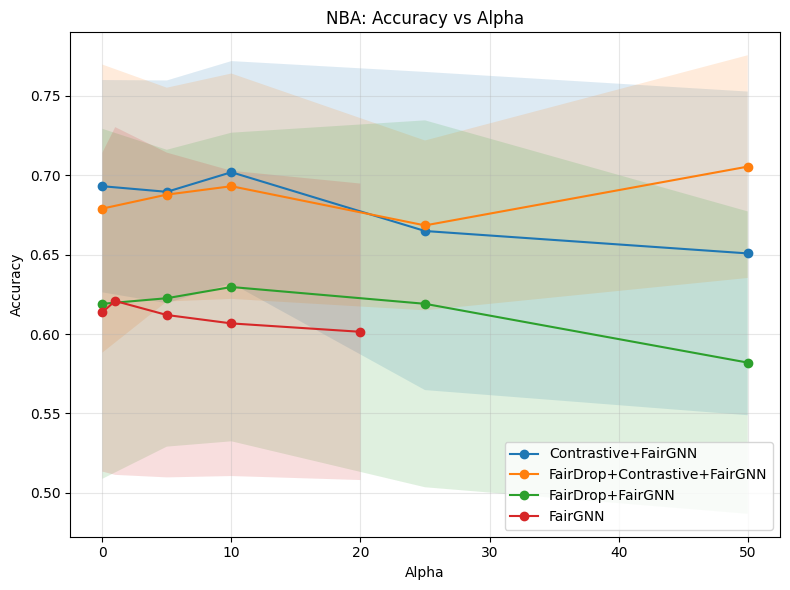

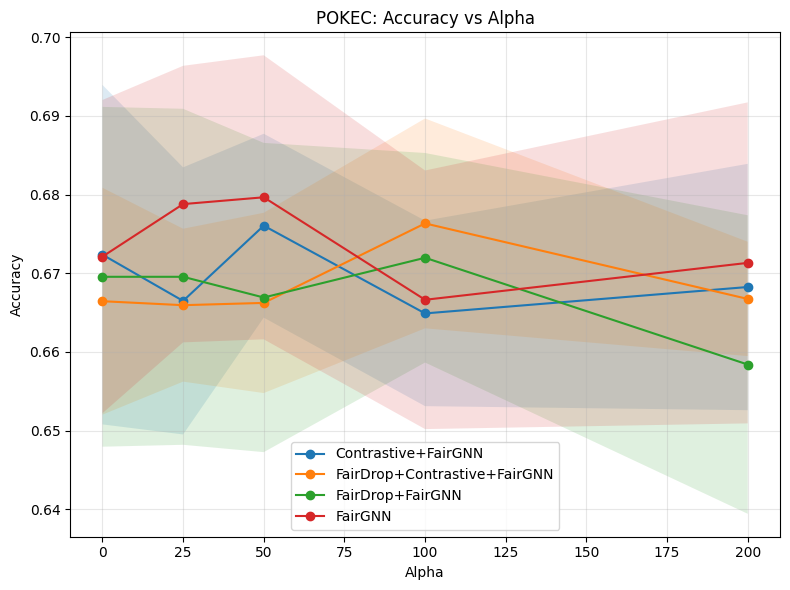

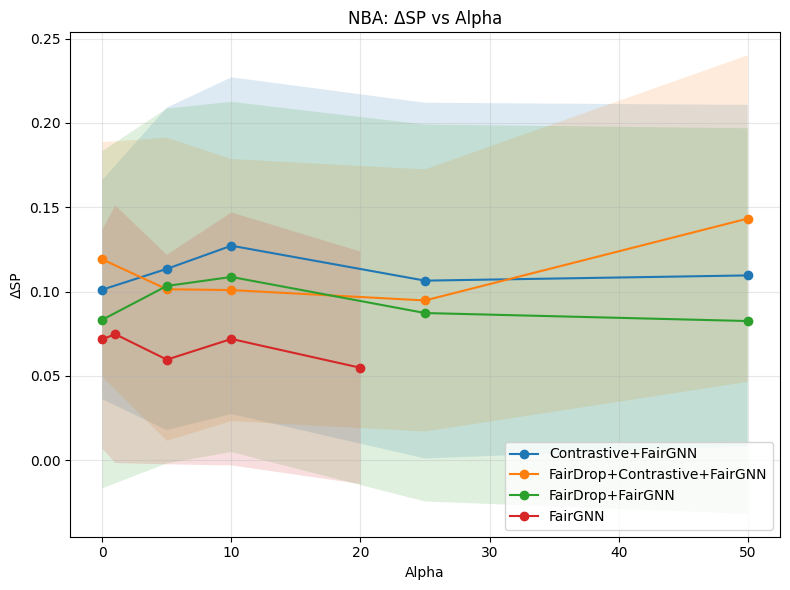

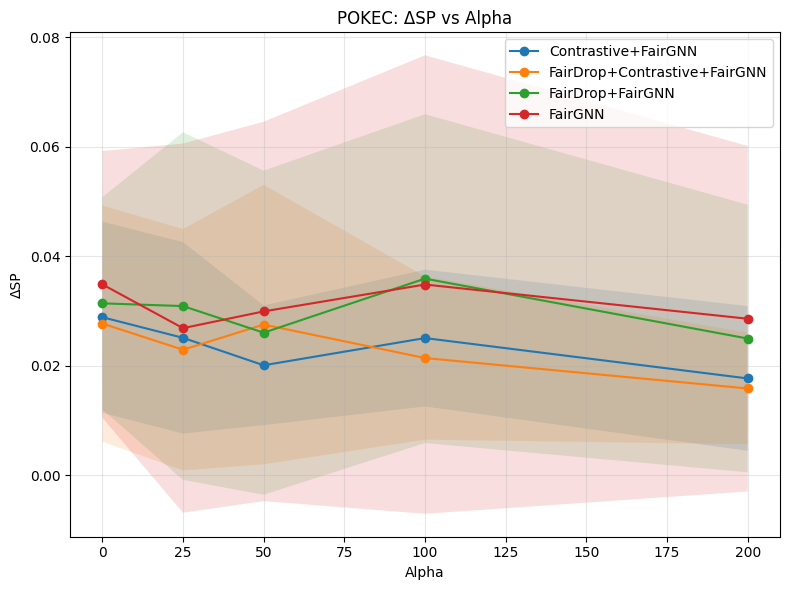

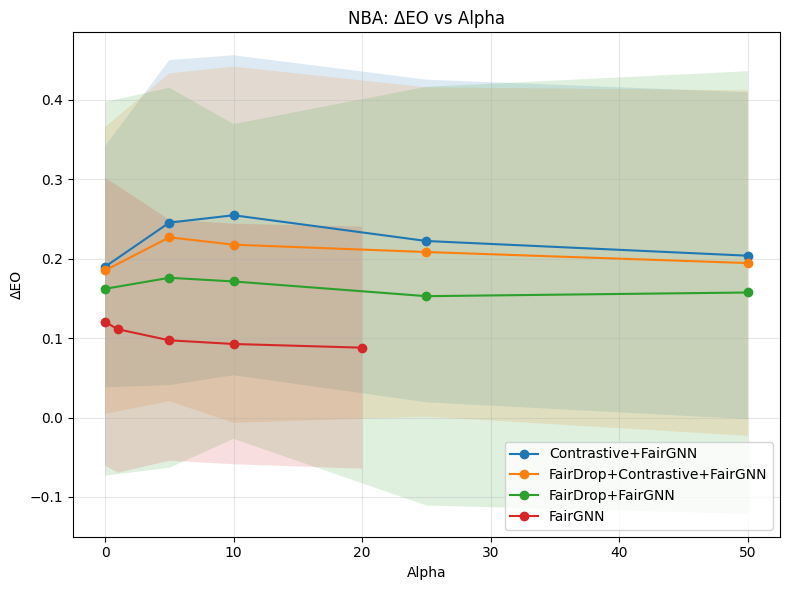

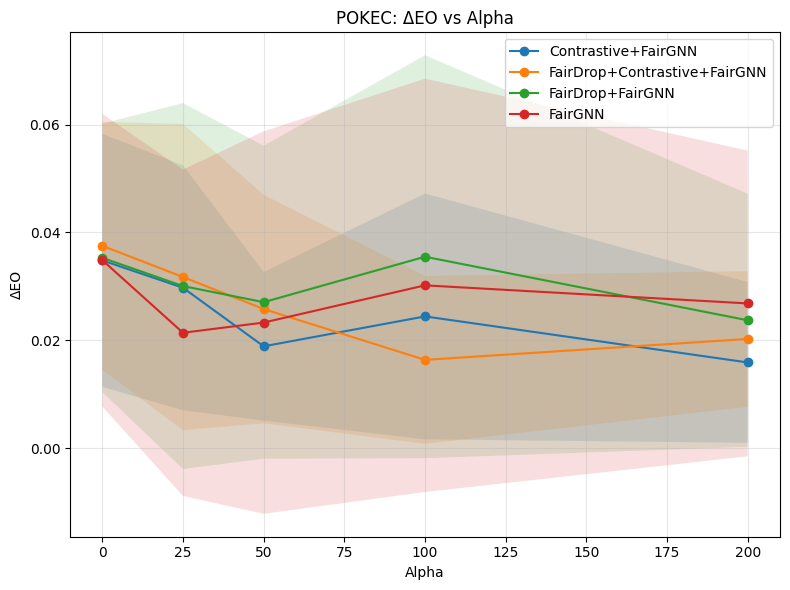

In [4]:
def plot_metric_vs_alpha(agg_df: pd.DataFrame, metric_key: str, ylabel: str):
    mean_col = f"{metric_key}_mean"
    std_col = f"{metric_key}_std"

    for dataset in sorted(agg_df["dataset"].unique()):
        plt.figure(figsize=(8, 6))
        sub = agg_df[agg_df["dataset"] == dataset]

        for method in sorted(sub["method"].unique()):
            m = sub[sub["method"] == method].sort_values("alpha")
            plt.plot(m["alpha"], m[mean_col], marker="o", label=method)
            plt.fill_between(
                m["alpha"],
                m[mean_col] - m[std_col],
                m[mean_col] + m[std_col],
                alpha=0.15
            )

        plt.xlabel("Alpha")
        plt.ylabel(ylabel)
        plt.title(f"{dataset.upper()}: {ylabel} vs Alpha")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        save_path = os.path.join(OUTPUT_DIR, f"{dataset}_{metric_key}_vs_alpha.png")
        plt.savefig(save_path, dpi=200)
        plt.show()

plot_metric_vs_alpha(agg_df, "acc", "Accuracy")
plot_metric_vs_alpha(agg_df, "sp", "ΔSP")
plot_metric_vs_alpha(agg_df, "eo", "ΔEO")

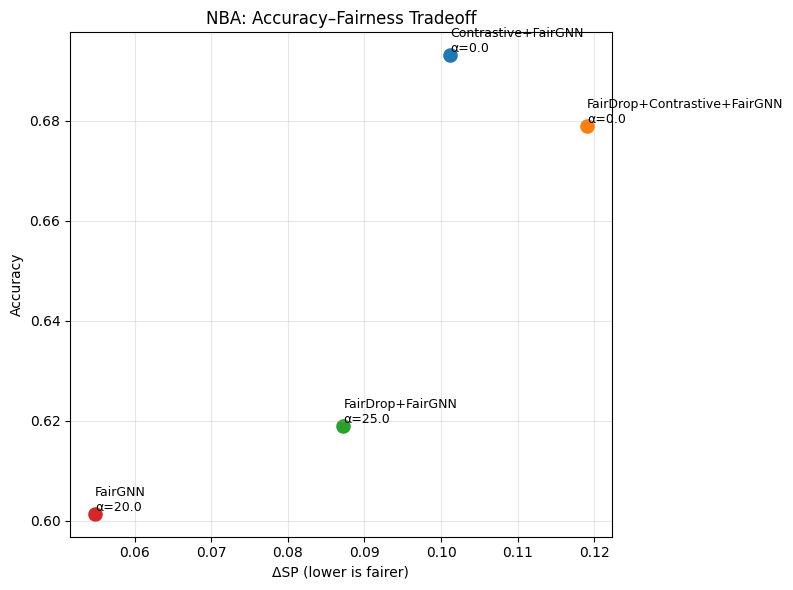

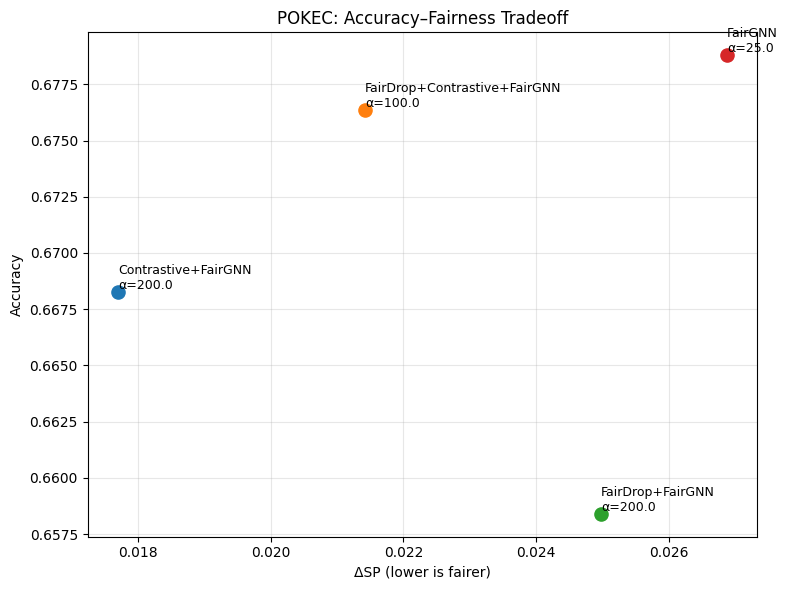

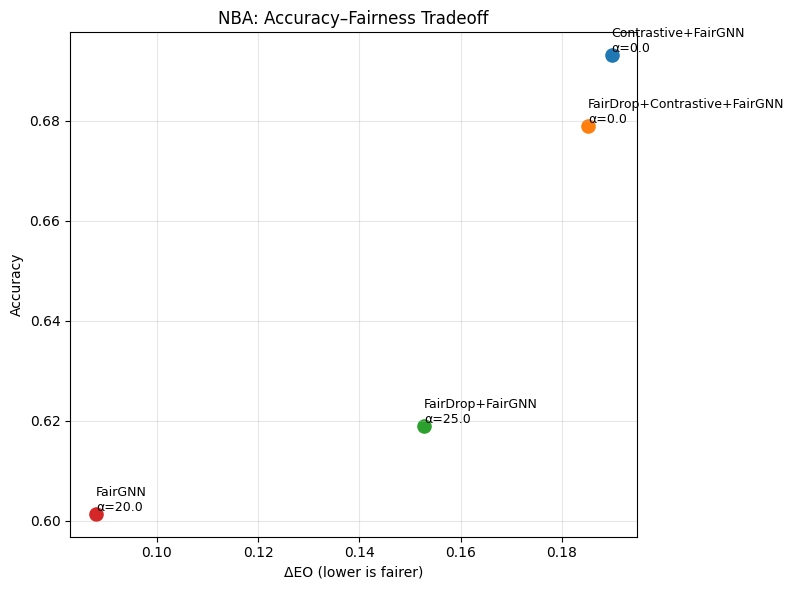

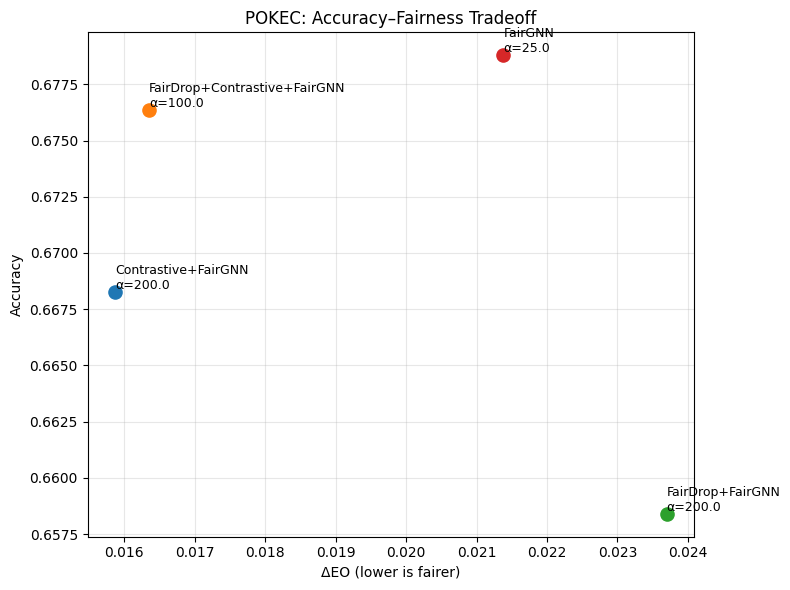

In [5]:
def plot_tradeoff(best_df: pd.DataFrame, fairness_axis: str = "sp"):
    if fairness_axis == "sp":
        x_col = "sp_mean"
        x_label = "ΔSP (lower is fairer)"
        fname = "tradeoff_acc_vs_sp.png"
    else:
        x_col = "eo_mean"
        x_label = "ΔEO (lower is fairer)"
        fname = "tradeoff_acc_vs_eo.png"

    for dataset in sorted(best_df["dataset"].unique()):
        plt.figure(figsize=(8, 6))
        sub = best_df[best_df["dataset"] == dataset]

        for _, row in sub.iterrows():
            plt.scatter(row[x_col], row["acc_mean"], s=90)
            plt.text(
                row[x_col], row["acc_mean"],
                f"{row['method']}\nα={row['alpha']}",
                fontsize=9, ha="left", va="bottom"
            )

        plt.xlabel(x_label)
        plt.ylabel("Accuracy")
        plt.title(f"{dataset.upper()}: Accuracy–Fairness Tradeoff")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        save_path = os.path.join(OUTPUT_DIR, f"{dataset}_{fname}")
        plt.savefig(save_path, dpi=200)
        plt.show()

plot_tradeoff(best_df, "sp")
plot_tradeoff(best_df, "eo")

In [11]:
def plot_tradeoff_all_alpha(agg_df: pd.DataFrame, fairness_axis: str = "sp"):

    if fairness_axis == "sp":
        x_col = "sp_mean"
        x_label = "ΔSP (lower is fairer)"
        fname = "tradeoff_acc_vs_sp_all_alpha.png"
    else:
        x_col = "eo_mean"
        x_label = "ΔEO (lower is fairer)"
        fname = "tradeoff_acc_vs_eo_all_alpha.png"

    for dataset in sorted(agg_df["dataset"].unique()):
        plt.figure(figsize=(8,6))

        sub = agg_df[agg_df["dataset"] == dataset]

        for method in sorted(sub["method"].unique()):

            m = sub[sub["method"] == method]

            plt.scatter(
                m[x_col],
                m["acc_mean"],
                s=80,
                label=method
            )

            # 顯示 alpha
            for _, row in m.iterrows():
                plt.text(
                    row[x_col],
                    row["acc_mean"],
                    f"{int(row['alpha'])}",
                    fontsize=8
                )

        plt.xlabel(x_label)
        plt.ylabel("Accuracy")
        plt.title(f"{dataset.upper()}: Accuracy–Fairness Tradeoff (All α)")
        plt.legend()
        plt.grid(True, alpha=0.3)

        save_path = os.path.join(OUTPUT_DIR, f"{dataset}_{fname}")
        plt.tight_layout()
        plt.savefig(save_path, dpi=200)
        plt.show()

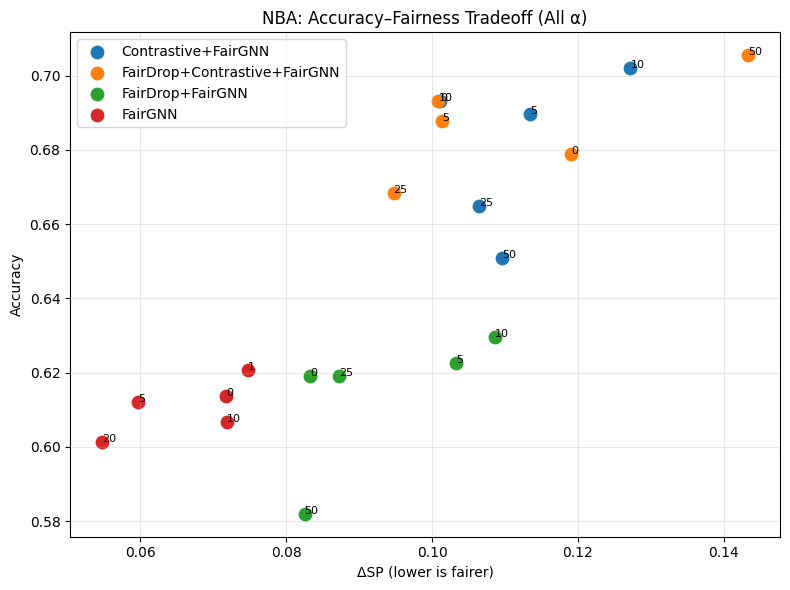

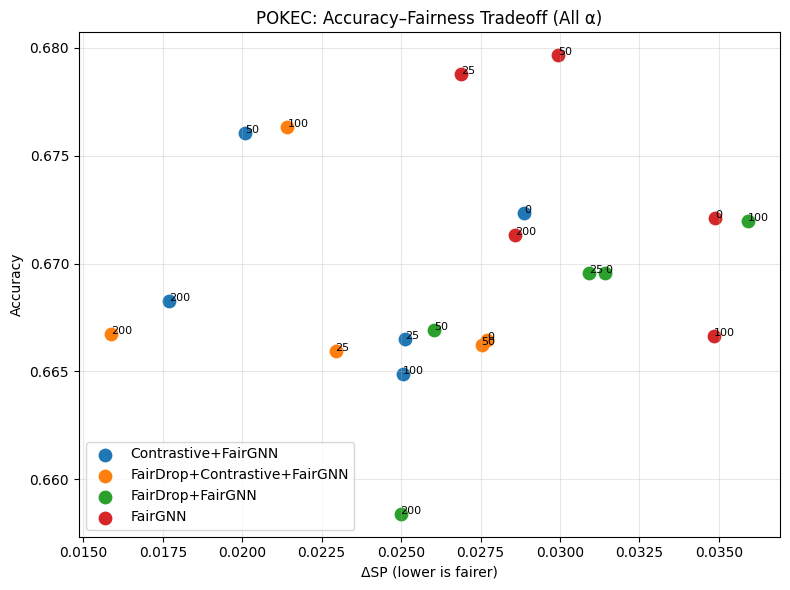

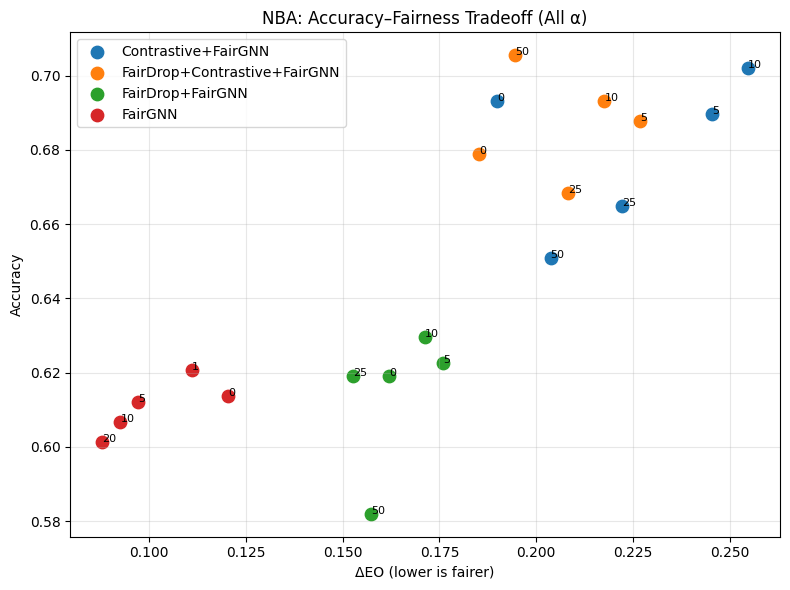

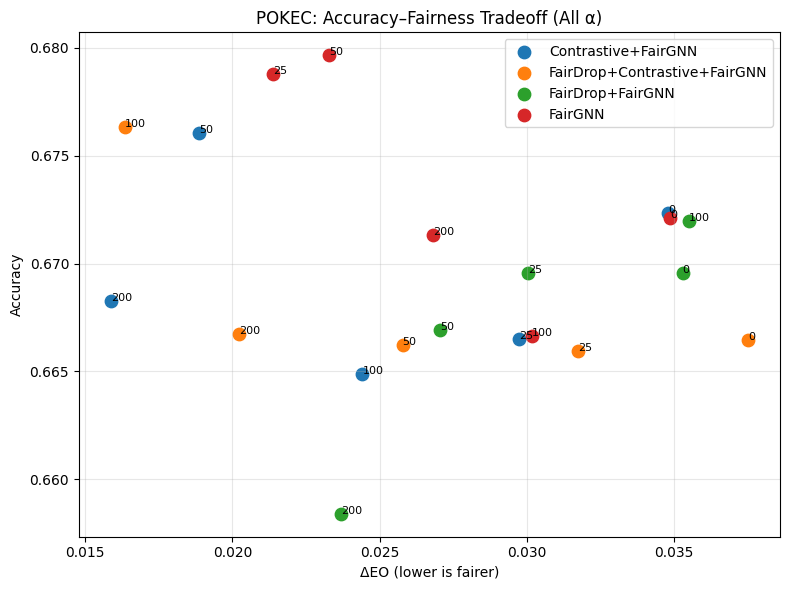

In [12]:
plot_tradeoff_all_alpha(agg_df, "sp")
plot_tradeoff_all_alpha(agg_df, "eo")

In [21]:
from matplotlib.patches import Ellipse

def plot_tradeoff_with_ellipse(agg_df: pd.DataFrame, fairness_axis: str = "sp"):
    if fairness_axis == "sp":
        x_col = "sp_mean"
        x_label = "ΔSP (lower is fairer)"
        fname = "tradeoff_with_ellipse_sp.png"
    else:
        x_col = "eo_mean"
        x_label = "ΔEO (lower is fairer)"
        fname = "tradeoff_with_ellipse_eo.png"

    for dataset in sorted(agg_df["dataset"].unique()):
        fig, ax = plt.subplots(figsize=(9, 7))
        sub = agg_df[agg_df["dataset"] == dataset].copy()

        for method in sorted(sub["method"].unique()):
            m = sub[sub["method"] == method].sort_values("alpha")

            # 原始點
            sc = ax.scatter(
                m[x_col],
                m["acc_mean"],
                s=70,
                alpha=0.55,
                label=method
            )

            color = sc.get_facecolor()[0]

            # alpha 標籤
            for _, row in m.iterrows():
                ax.text(
                    row[x_col],
                    row["acc_mean"],
                    f"{row['alpha']}",
                    fontsize=8
                )

            # 平均與分布
            x_mean = m[x_col].mean()
            y_mean = m["acc_mean"].mean()
            x_std = m[x_col].std()
            y_std = m["acc_mean"].std()

            # 平均點
            ax.scatter(
                x_mean,
                y_mean,
                s=180,
                edgecolors="black",
                linewidths=1.2,
                color=color,
                zorder=5
            )

            # 半透明 ellipse
            if pd.notna(x_std) and pd.notna(y_std):
                ellipse = Ellipse(
                    (x_mean, y_mean),
                    width=2 * x_std,
                    height=2 * y_std,
                    facecolor=color,
                    alpha=0.18,
                    edgecolor=color,
                    linewidth=1.5
                )
                ax.add_patch(ellipse)

        ax.set_xlabel(x_label)
        ax.set_ylabel("Accuracy")
        ax.set_title(f"{dataset.upper()}: Accuracy–Fairness Tradeoff")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9, loc="best")
        plt.tight_layout()

        save_path = os.path.join(OUTPUT_DIR, f"{dataset}_{fname}")
        plt.savefig(save_path, dpi=200)
        plt.show()

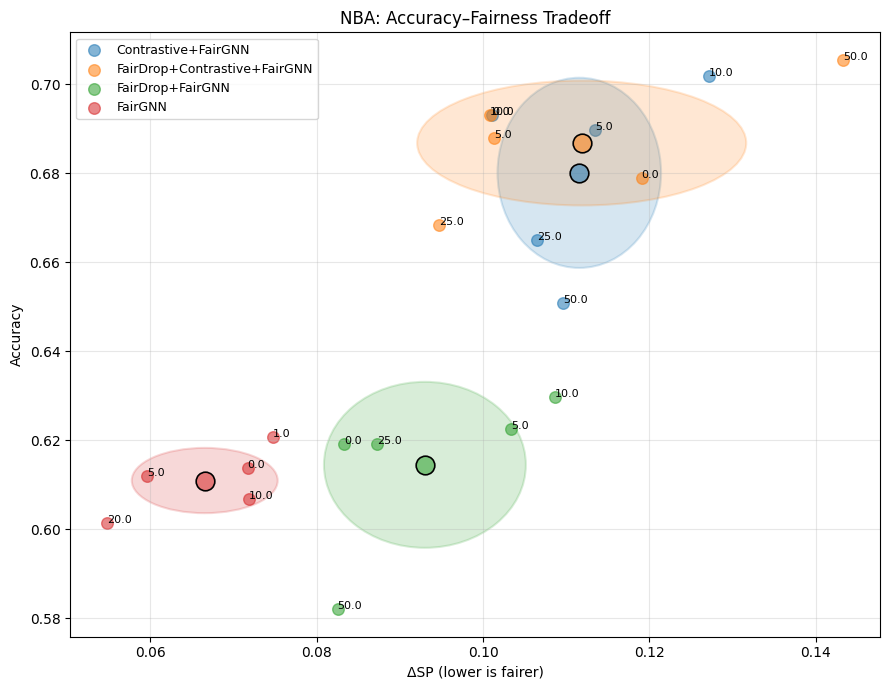

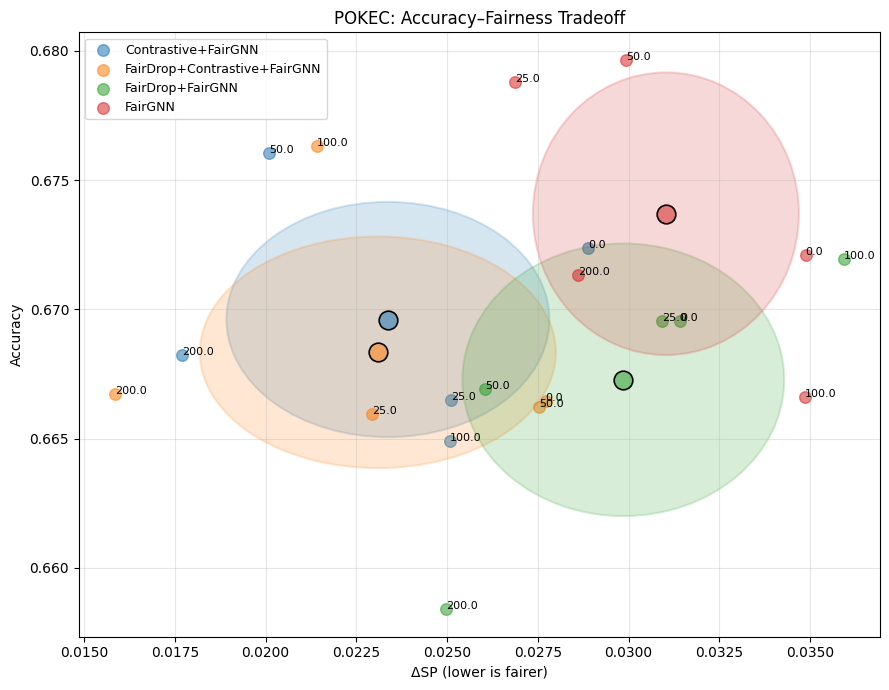

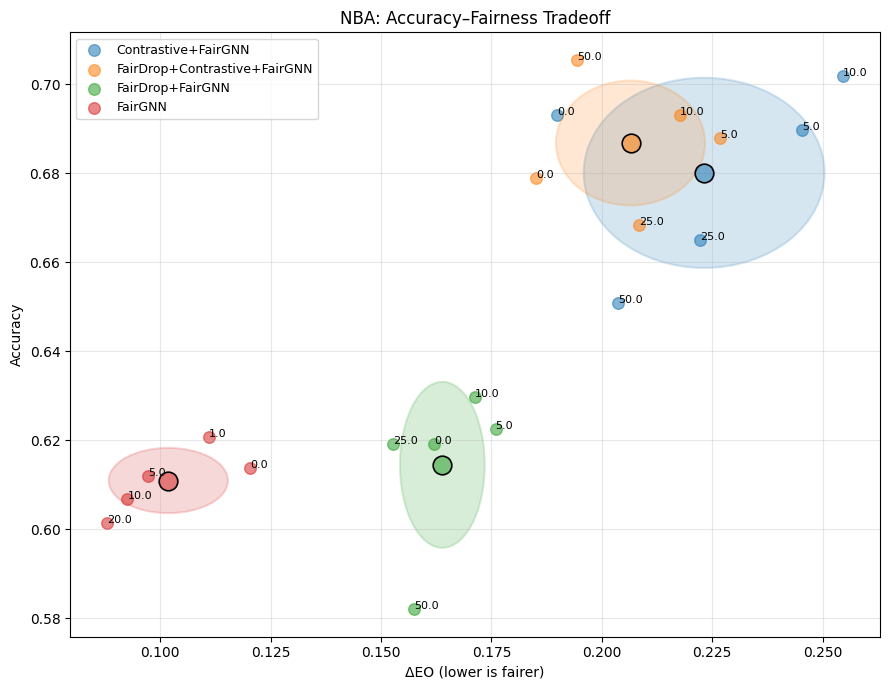

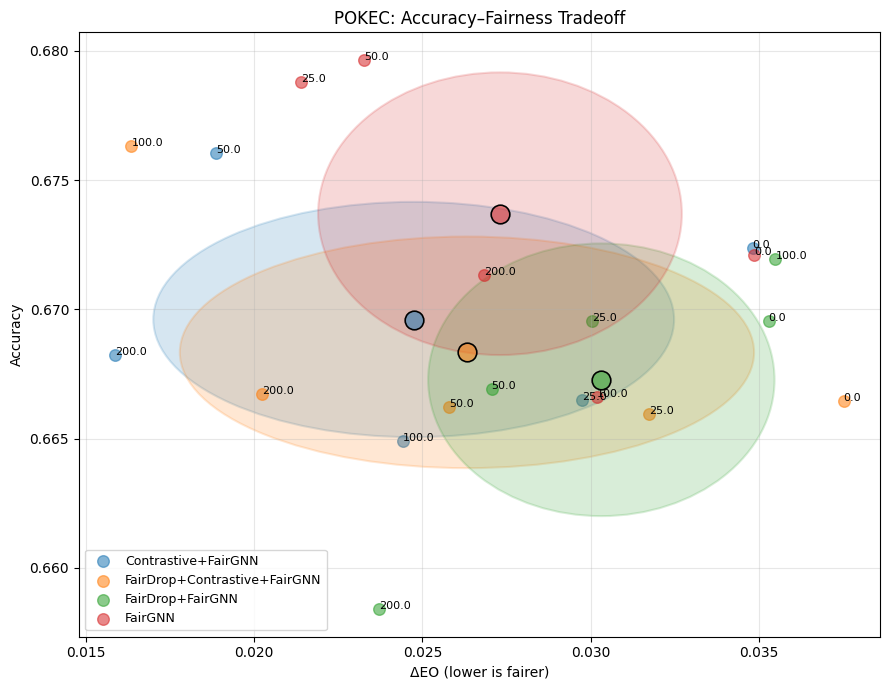

In [22]:
plot_tradeoff_with_ellipse(agg_df, "sp")
plot_tradeoff_with_ellipse(agg_df, "eo")

In [6]:
def plot_fixed_alpha_bars(agg_df: pd.DataFrame, fixed_alpha: float):
    metrics = [
        ("acc_mean", "Accuracy", "accuracy"),
        ("sp_mean", "ΔSP", "sp"),
        ("eo_mean", "ΔEO", "eo"),
    ]

    for dataset in sorted(agg_df["dataset"].unique()):
        sub = agg_df[(agg_df["dataset"] == dataset) & (np.isclose(agg_df["alpha"], fixed_alpha))].copy()
        if sub.empty:
            print(f"No rows for dataset={dataset}, alpha={fixed_alpha}")
            continue

        sub = sub.sort_values("method")
        for metric_col, ylabel, suffix in metrics:
            plt.figure(figsize=(9, 5))
            plt.bar(sub["method"], sub[metric_col])
            plt.xticks(rotation=20, ha="right")
            plt.ylabel(ylabel)
            plt.title(f"{dataset.upper()}: {ylabel} at Alpha={fixed_alpha}")
            plt.tight_layout()
            save_path = os.path.join(OUTPUT_DIR, f"{dataset}_{suffix}_alpha_{fixed_alpha}.png")
            plt.savefig(save_path, dpi=200)
            plt.show()

if FIXED_ALPHA is not None:
    plot_fixed_alpha_bars(agg_df, FIXED_ALPHA)
else:
    print("FIXED_ALPHA is None, skip fixed-alpha bar charts.")

FIXED_ALPHA is None, skip fixed-alpha bar charts.


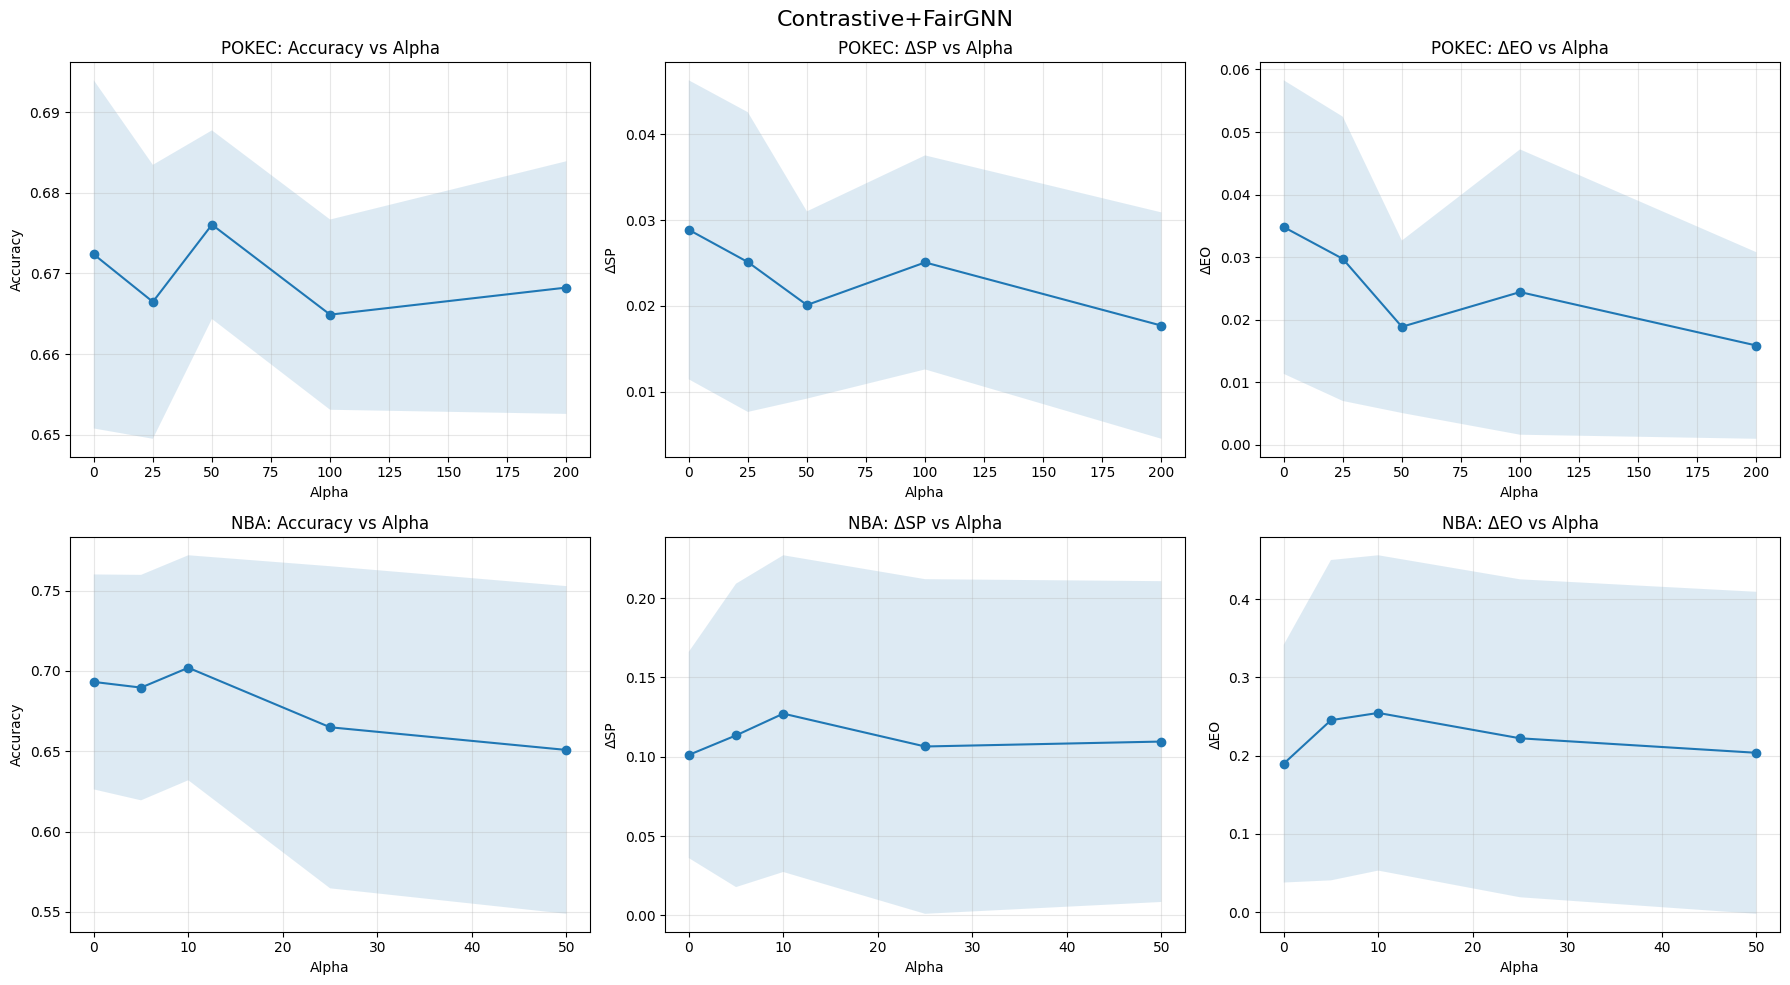

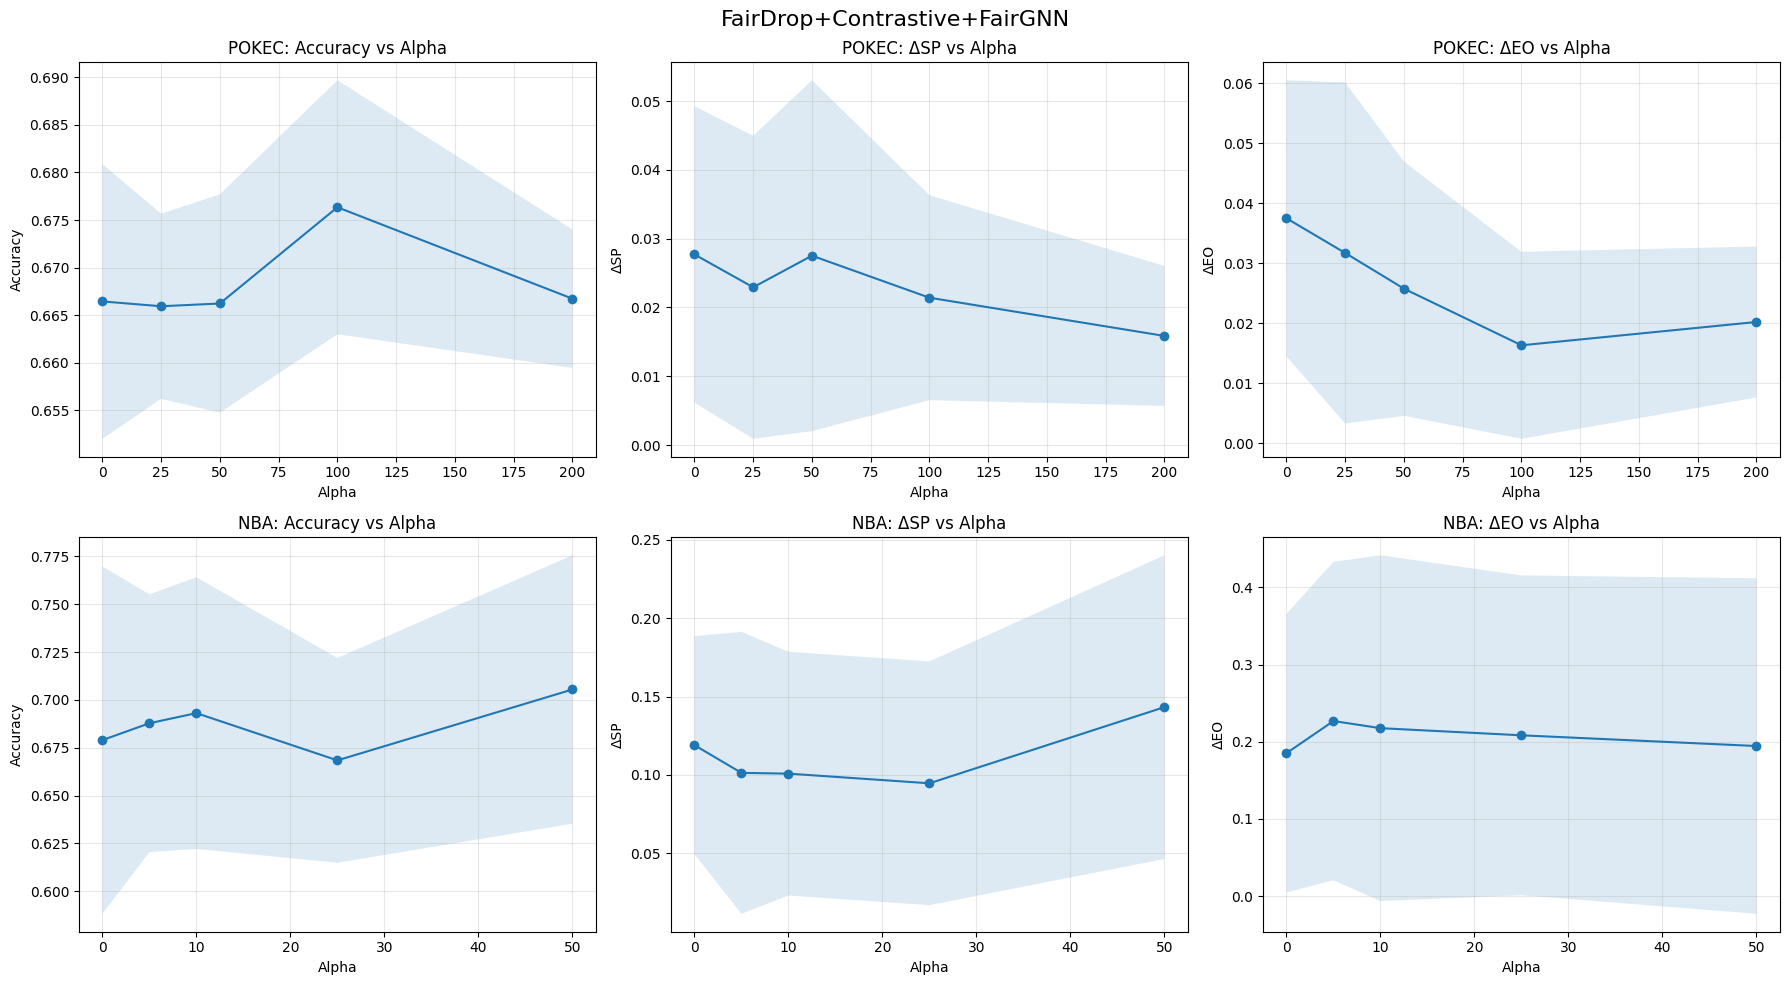

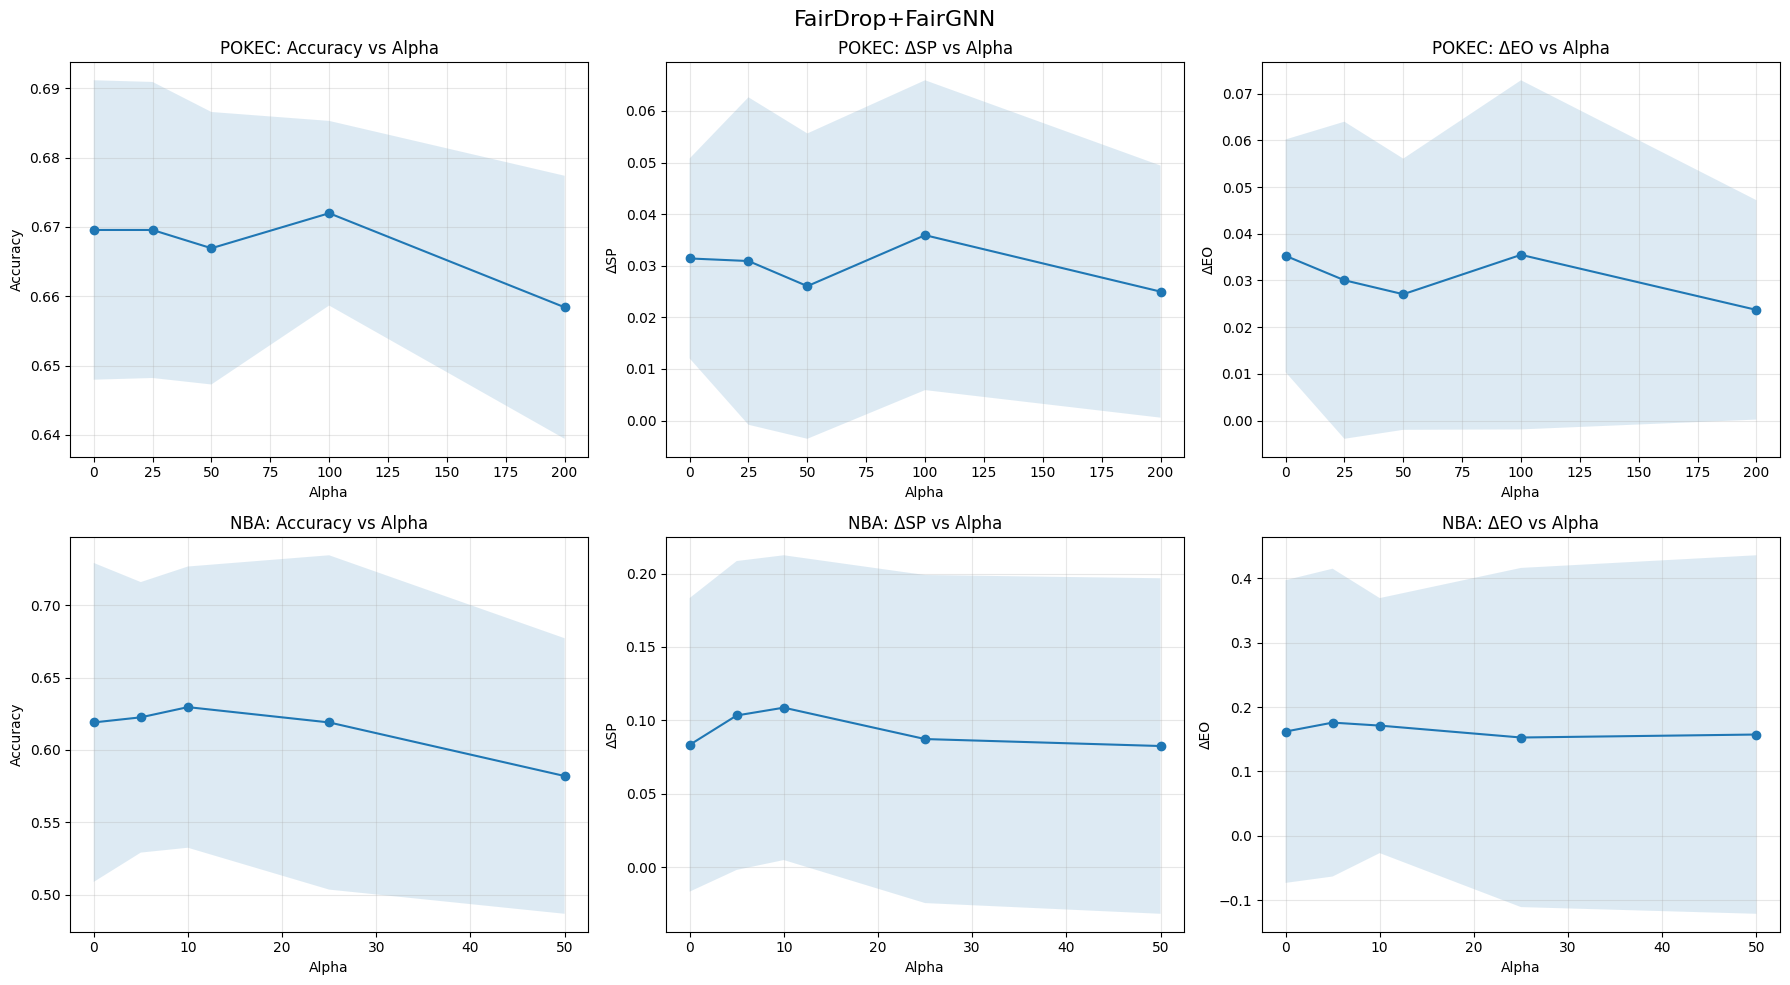

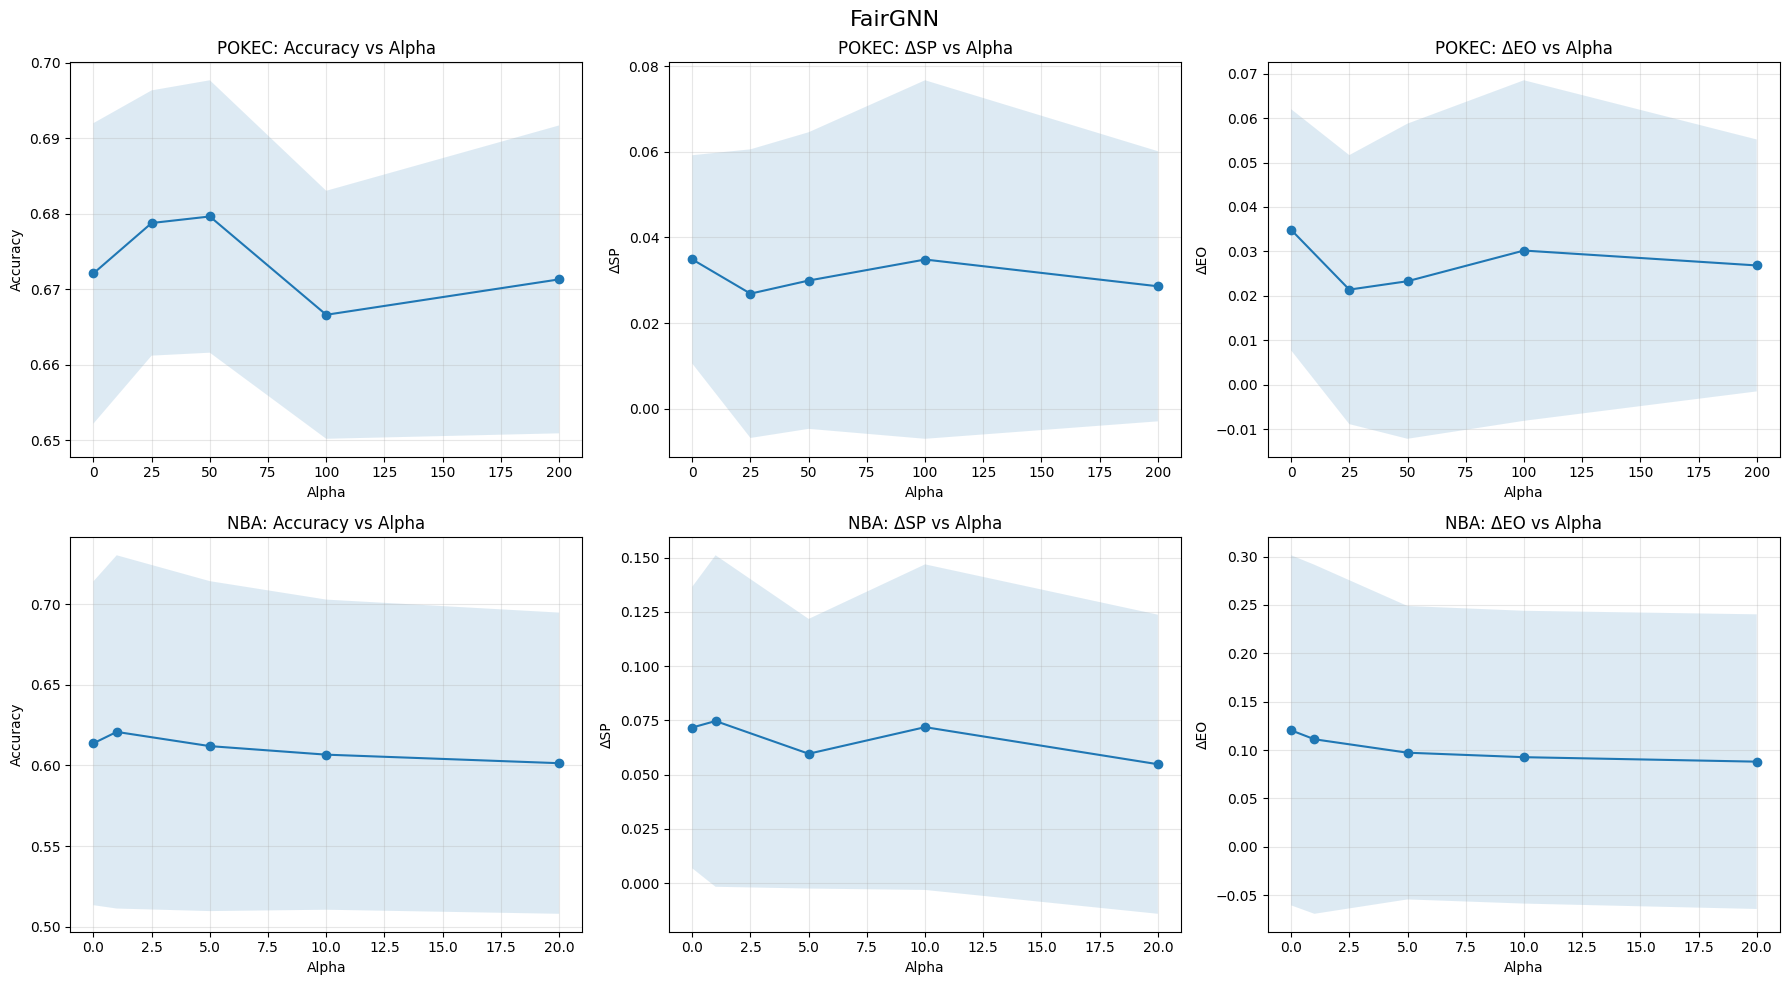

In [7]:
def plot_method_2x3(agg_df: pd.DataFrame, method: str):
    sub = agg_df[agg_df["method"] == method].copy()
    datasets = [d for d in ["pokec", "nba"] if d in sub["dataset"].unique()]
    if not datasets:
        return

    fig, axes = plt.subplots(len(datasets), 3, figsize=(18, 5 * len(datasets)))
    if len(datasets) == 1:
        axes = np.array([axes])

    for i, ds in enumerate(datasets):
        s = sub[sub["dataset"] == ds].sort_values("alpha")

        axes[i, 0].plot(s["alpha"], s["acc_mean"], marker="o")
        axes[i, 0].fill_between(s["alpha"], s["acc_mean"] - s["acc_std"], s["acc_mean"] + s["acc_std"], alpha=0.15)
        axes[i, 0].set_title(f"{ds.upper()}: Accuracy vs Alpha")
        axes[i, 0].set_xlabel("Alpha")
        axes[i, 0].set_ylabel("Accuracy")
        axes[i, 0].grid(True, alpha=0.3)

        axes[i, 1].plot(s["alpha"], s["sp_mean"], marker="o")
        axes[i, 1].fill_between(s["alpha"], s["sp_mean"] - s["sp_std"], s["sp_mean"] + s["sp_std"], alpha=0.15)
        axes[i, 1].set_title(f"{ds.upper()}: ΔSP vs Alpha")
        axes[i, 1].set_xlabel("Alpha")
        axes[i, 1].set_ylabel("ΔSP")
        axes[i, 1].grid(True, alpha=0.3)

        axes[i, 2].plot(s["alpha"], s["eo_mean"], marker="o")
        axes[i, 2].fill_between(s["alpha"], s["eo_mean"] - s["eo_std"], s["eo_mean"] + s["eo_std"], alpha=0.15)
        axes[i, 2].set_title(f"{ds.upper()}: ΔEO vs Alpha")
        axes[i, 2].set_xlabel("Alpha")
        axes[i, 2].set_ylabel("ΔEO")
        axes[i, 2].grid(True, alpha=0.3)

    plt.suptitle(method, fontsize=16)
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"{method.replace('+', '_plus_')}_2x3_summary.png")
    plt.savefig(save_path, dpi=200)
    plt.show()

for method in agg_df["method"].unique():
    plot_method_2x3(agg_df, method)

In [8]:
print("=== Best alpha summary ===")
cols = ["method", "dataset", "alpha", "acc_mean", "sp_mean", "eo_mean", "n_runs"]
display(best_df[cols].sort_values(["dataset", "method"]))

print("\nSaved files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(" -", f)

=== Best alpha summary ===


,method,dataset,alpha,acc_mean,sp_mean,eo_mean,n_runs
0,Contrastive+FairGNN,nba,0.0,0.693122,0.101129,0.189815,9
2,FairDrop+Contrastive+FairGNN,nba,0.0,0.679012,0.119050,0.185185,9
4,FairDrop+FairGNN,nba,25.0,0.619048,0.087262,0.152778,9
6,FairGNN,nba,20.0,0.601411,0.054801,0.087963,9
1,Contrastive+FairGNN,pokec,200.0,0.668254,0.017696,0.015873,9
3,FairDrop+Contrastive+FairGNN,pokec,100.0,0.676338,0.021422,0.016352,9
5,FairDrop+FairGNN,pokec,200.0,0.658403,0.024983,0.023699,9
7,FairGNN,pokec,25.0,0.678792,0.026878,0.021382,9



Saved files:
 - Contrastive_plus_FairGNN_2x3_summary.png
 - FairDrop_plus_Contrastive_plus_FairGNN_2x3_summary.png
 - FairDrop_plus_FairGNN_2x3_summary.png
 - FairGNN_2x3_summary.png
 - all_methods_aggregated.csv
 - all_methods_raw_merged.csv
 - best_alpha_per_method_dataset.csv
 - nba_acc_vs_alpha.png
 - nba_eo_vs_alpha.png
 - nba_sp_vs_alpha.png
 - nba_tradeoff_acc_vs_eo.png
 - nba_tradeoff_acc_vs_sp.png
 - pokec_acc_vs_alpha.png
 - pokec_eo_vs_alpha.png
 - pokec_sp_vs_alpha.png
 - pokec_tradeoff_acc_vs_eo.png
 - pokec_tradeoff_acc_vs_sp.png
